In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf 
import seaborn as sns

sns.set_style("whitegrid")

tf.keras.utils.set_random_seed(42)

column_names = ['Sex','Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','Rings']

# Load presplit X/y if exist, otherwise read raw data for analysis
try:
    X = pd.read_csv('data/X.csv')
    y = pd.read_csv('data/y.csv')
    
except FileNotFoundError:
    data = pd.read_csv("data/abalone.data", header=None)
    X, y = [], []
    data.columns = column_names


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def process_data(data, standardise=False):
    """Process and split raw data

    Args:
        data (pd.DataFrame): data frame of full, raw data

    Returns:
        tuple: X - dataframe of features, y - dataframe of response
    """
    # Add Rings_class column
    abalone_data = data.copy()
    abalone_data["Rings_class"] = 0

    # Define X and y columns
    x_cols = ['Sex','Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight']
    y_cols = 'Rings_class'
    numeric_cols = ['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight']
    
    # Dictionary of class splits
    classes = {
        0: (min(data["Rings"])-1,7),
        1: (7, 10),
        2: (10, 15),
        3: (15, max(data["Rings"]))
    }

    # Split data into classes
    for key, value in classes.items():
        abalone_data["Rings_class"] = abalone_data.apply(
            lambda ring_age: key if (ring_age["Rings"] > value[0] and ring_age["Rings"] <= value[1]) else ring_age["Rings_class"], axis=1
        )
        

    # Drop Rings column and split data into X and y
    abalone_data.drop(columns=["Rings"], inplace=True)
    X = abalone_data.loc[:,x_cols]
    y = abalone_data.loc[:, y_cols]

    if standardise:
        X = X.loc[~(X['Height'] >= 1) & ~(X['Height'] == 0), :] # Remove impossible height outliers (0 or height >= length)
        # Standardise numeric columns
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X.loc[:, numeric_cols])
        X.loc[:, numeric_cols] = X_scaled
        X = pd.get_dummies(X, "Sex", dtype=int) # One-hot encode "Sex" column
        
    return X, y

# If no cached X/y split, process raw data for analysis
if len(X) == 0 or len(y) == 0:
    X, y = process_data(data, standardise=True)
    X.to_csv('data/X.csv', index=False)
    y.to_csv('data/y.csv', index=False)


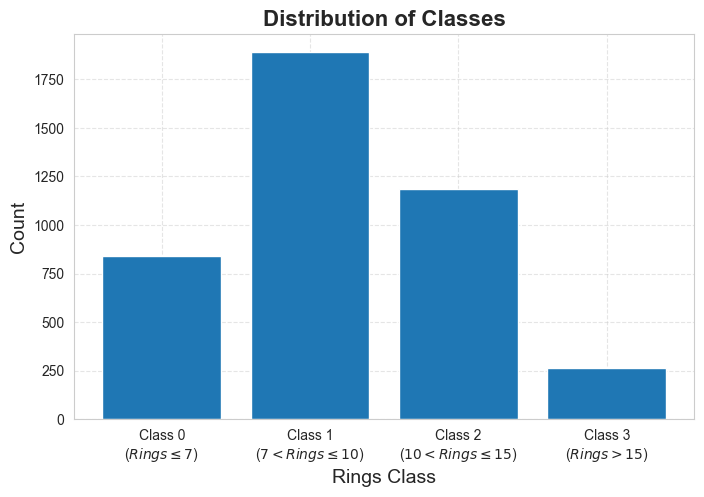

In [15]:
# Class Distribution
classes_list = ["Class 0\n"r"($Rings \leq 7$)", "Class 1\n"r"($7 < Rings \leq10$)", "Class 2\n"r"($10 < Rings \leq 15$)", "Class 3\n"r"($Rings > 15$)"]

# Group by class for plotting
all_data = pd.concat((X, y), axis=1)
all_data["count"] = 1 # constant column to count rows per class
grouped_count = all_data.groupby('Rings_class').agg('count')

plt.figure(figsize=(8,5))
plt.bar(grouped_count.index, grouped_count["count"])
plt.xticks(ticks=grouped_count.index, labels=classes_list)
plt.xlabel("Rings Class", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.title("Distribution of Classes", fontsize=16, weight='bold')
plt.savefig('./figures/ClassDistribution.png', bbox_inches='tight', dpi=300)

In [16]:
# Process raw data for plotting
data = pd.read_csv("data/abalone.data", header=None)
data.columns = ['Sex','Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','Rings']
X_og, y_og = process_data(data)

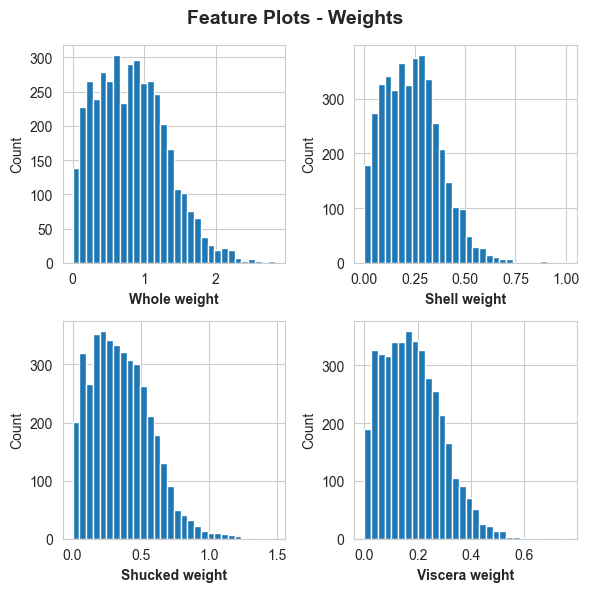

In [17]:
# Plot of weight related features
plot_order = ['Whole weight', 'Shell weight', 'Shucked weight', 'Viscera weight']
fig, axes = plt.subplots(2, 2)
for  i, ax in enumerate(axes.flatten()):
    ax.hist(X_og.loc[:, plot_order[i]], bins=30)
    ax.set_xlabel(plot_order[i], fontsize=10, weight='bold')
    ax.set_ylabel("Count", fontsize=10)

fig.set_size_inches(6, 6)
fig.suptitle("Feature Plots - Weights",  fontsize=14, weight='bold')
fig.tight_layout()
fig.savefig('figures/Feature_plots_weights.png', bbox_inches='tight', dpi=300)

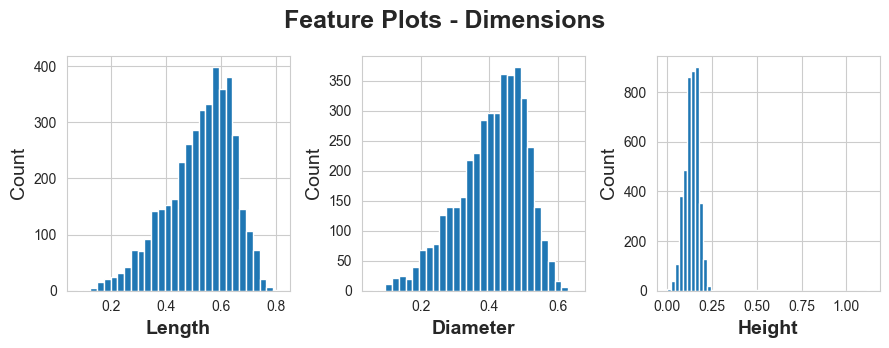

In [18]:
# Plot of dimension related features
plot_order = ['Length', 'Diameter', 'Height']
fig, axes = plt.subplots(1, 3)
for  i, ax in enumerate(axes.flatten()):
    if plot_order[i] == '':
        continue
    num_bins=30
    if i==2:
        num_bins=50
    ax.hist(X_og.loc[:, plot_order[i]], bins=num_bins)
    ax.set_xlabel(plot_order[i], fontsize=14, weight='bold')
    ax.set_ylabel("Count", fontsize=14)

fig.set_size_inches(9, 3.5)
fig.suptitle("Feature Plots - Dimensions",  fontsize=18, weight='bold')

fig.tight_layout()
fig.savefig('figures/Feature_plots_dimensions.png', bbox_inches='tight', dpi=300)

Sex
F    1307
I    1342
M    1528
Name: Count, dtype: int64


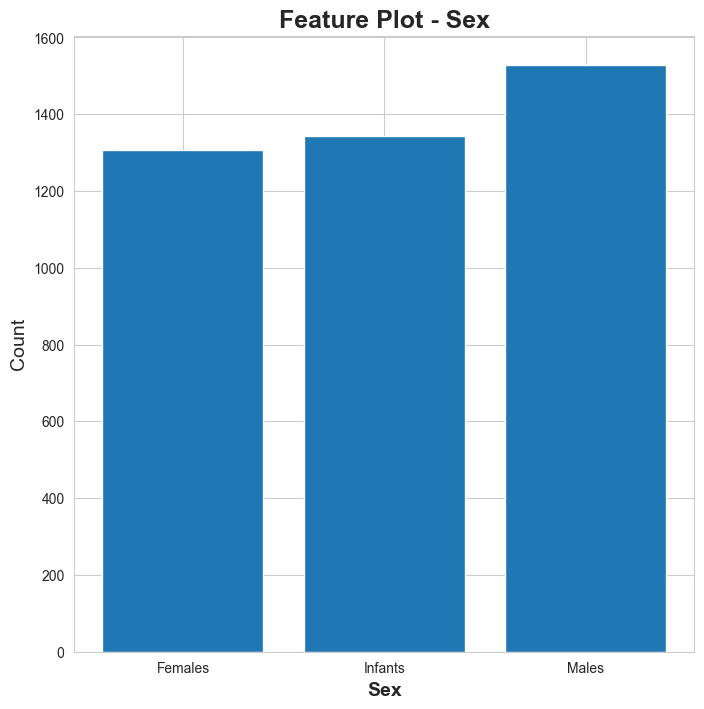

In [19]:
# Plot of response
plot_order = ['Sex']
X_og['Count'] = 1 # constant column to count rows

# Distribution of response
sex_count = X_og.groupby('Sex').count()['Count']
print(sex_count)

fig = plt.figure()
fig.set_size_inches(8, 8)
fig.tight_layout()
plt.bar(['Females', 'Infants', 'Males'], sex_count.values)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Sex', fontsize=14, weight='bold')
plt.ylabel("Count", fontsize=14)
plt.title("Feature Plot - Sex",  fontsize=18, weight='bold')

plt.savefig('figures/Feature_plots_sex.png', bbox_inches='tight', dpi=300)

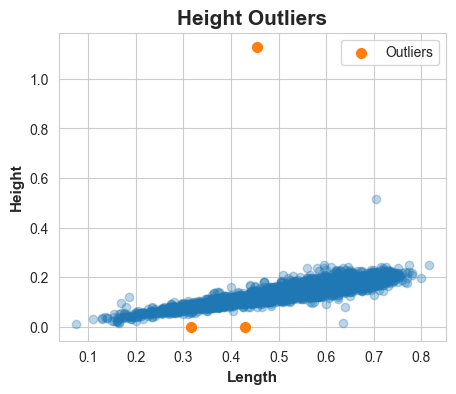

In [20]:
# Plot outliers (impossible values) - removed in process_data function
plot_order = ['Sex']

fig = plt.figure()
fig.set_size_inches(5, 4)
fig.tight_layout()

h_scatter = X_og['Height']
l_scatter = X_og['Length']
lims = (h_scatter > 1) | (h_scatter == 0)

plt.scatter(l_scatter[~lims],h_scatter[~lims], alpha=0.3)
plt.scatter(l_scatter[lims], h_scatter[lims], s=50, label="Outliers")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Length', fontsize=11, weight='bold')
plt.ylabel("Height", fontsize=11, weight='bold')
plt.legend()
plt.title("Height Outliers",  fontsize=15, weight='bold')

plt.savefig('figures/Feature_plots_outliers.png', bbox_inches='tight', dpi=300)


In [21]:
# Create dense Neural Network for experiments
import time

def create_model(hidden_neurons, hidden_layers):
    """Create a Neural Network with a given number of hidden neurons and layers

    Args:
        hidden_neurons (int): Number of hidden neurons per hidden layer
        hidden_layers (int): Number of hidden layers

    Returns:
        tf.keras.Sequential: keras Sequential model 
    """
    classes_list = ["Class 0\n(Rings <= 7)", "Class 1\n(7 < Rings <=10)", "Class 2\n(10 < Rings <= 15)", "Class 3\n(Rings > 15)"]
    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(X.shape[1],)))
    # add hidden layers
    for i in range(hidden_layers): 
        model.add(tf.keras.layers.Dense(units=hidden_neurons, activation='relu', name=f"hidden_{i}"))
    model.add(tf.keras.layers.Dense(units=len(classes_list), activation='softmax', name='output'))   
    
    return model
    
def set_optimizer(optimizer, learning_rate):
    """Creates optimizer to be used in model

    Args:
        optimizer (str): which optimizer to be used
        learning_rate (float): learning rate

    Returns:
        tf.keras.optimizers: keras optimizer (SGD or Adam)
    """
    
    if optimizer=='sgd':
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
        return optimizer
    else: #optimizer_alg=='adam'
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
        return optimizer
        
def generate_NN(x_data, y_data, hidden_neurons, learning_rate, hidden_layers, optimizer, batch_size=32, epochs=100, verbose=0, validation_data=None):
    """To generate  Neural Network with chosen hidden layers, neurons and optimizer.
    
    Args:
        hidden_neurons (int): Number of Neurons in hidden layer
        batch_size (int): size of mini-batch for SGD
        x_data (pd.DataFrame): DataFrame of predictors
        y_data (pd.Series): DataFrame of labels
        epochs (int, optional): Number of Epochs to run. Defaults to 50.

    Returns:
        dict: dictionary including model, test accuracy, history of training
    """
    # create and compile model
    model = create_model(hidden_neurons, hidden_layers)
    keras_optimizer = set_optimizer(optimizer, learning_rate)
    model.compile(optimizer=keras_optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])  
        
    # fit and time model
    start_time = time.time()
    history = model.fit(x=x_data['x_train'], y=y_data['y_train'], batch_size=batch_size, epochs=epochs, verbose=verbose, validation_data=validation_data)
    end_time = time.time()
    training_time = (end_time - start_time)
    
    # test model
    test_eval = model.evaluate(x = x_data['x_test'], y=y_data['y_test'], batch_size=batch_size)
    
    return {'model': model,
            'test_eval': test_eval,
            'history': history.history,
            'training_time': training_time}


In [22]:
# Generate NN models for parameters being tested - N experiments for each
from scipy import stats

def valid_parameter(parameter):
    """Check if parameter being experimented is valid for our tests (layers, neurons, learning rate, optimizer)

    Args:
        parameter (str): NN model parameter

    Returns:
        bool: True - is valid parameter
    """
    
    allowed_parameters = ['hidden_neurons', 'hidden_layers', 'learning_rate', 'optimizer']
    if parameter in allowed_parameters:
        return True
    print(f"Parameter must be one of {allowed_parameters}")
    return False
    
def set_learning_rate(parameter, value, parameter_dict):
    """Set learning rate if parameter = 'optimizer', ie. optimizer is the parameter being experimented on

    Args:
        parameter (str): parameter being experimented on
        value (float, str, int): value of parameter
        parameter_dict (_type_): dictionary of all model parameters

    Returns:
        float: learning rate to use
    """
    
    allowed_optimizers = ["adam", "sgd"]
    optimizer_alg = parameter_dict["optimizer"]
    
    if optimizer_alg not in allowed_optimizers:
        print(f"Optimizer must be one of {allowed_optimizers}")
        return ValueError
    
    if parameter == "optimizer": # optimizer is being experimented
        return value
    else: # optimizer is set
        return parameter_dict['learning_rate']

    
    
def run_experiments(x_data, y_data, parameter, parameter_values, parameter_dict_input, epochs=103, batch_size=32, num_experiments=10):   
    """Creates 1 NN per experiment, fits and tests it

    Args:
        x_data (dict): dictionary of training and testing data for X
        y_data (dict): dictionary of training and testing data for y
        parameter (str): parameter being experimented
        parameter_values (list): list of parameter values
        parameter_dict_input (dict): input model parameters
        epochs (int, optional): Number of epochs. Defaults to 140.
        batch_size (int, optional): mini batch size. Defaults to 32.
        num_experiments (int, optional): Number of Experiments. Defaults to 10.

    Returns:
        dict: dictionary of various model information
    """
    
    if not valid_parameter(parameter): #invalid parameter - end experiments
        return
    
    models = {'parameter_details': {'parameter':parameter, 'values': parameter_values},
              'models': {}}

    parameter_dict = parameter_dict_input.copy()
    
    parameters_modelled = 0    
    for value in parameter_values:
        
        models['models'][value] = []
        parameter_dict[parameter] = value
        
        for _ in range(num_experiments):
            
            # generate model for experiment
            parameter_dict["learning_rate"] = set_learning_rate(parameter, value, parameter_dict_input)
            
            model = generate_NN(
                batch_size=batch_size, 
                epochs=epochs,
                x_data=x_data,
                y_data=y_data,
                **parameter_dict
            )
            
            models['models'][value].append(model)
          
        parameters_modelled += 1
        
        print(f"\n\nModels Generated for {parameter}: {value}\nParameters left to model: {len(parameter_values) - parameters_modelled}")
        
    return models
        


In [23]:
# Split data, choose best epochs
from sklearn.model_selection import train_test_split

x_cols = ['Sex_M', 'Sex_F', 'Sex_I', 'Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight']
y_cols = 'Rings_class'

# split data into train and test
try:
    # Use cached splits if available
    train_data = pd.read_csv('data/train_data.csv')
    test_data = pd.read_csv('data/test_data.csv')

except FileNotFoundError:
    x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.4, random_state=42, stratify=y)
    train_data = pd.concat((x_train, y_train),axis=1)
    test_data = pd.concat((x_test, y_test),axis=1)
    train_data.to_csv('data/train_data.csv', index=False)
    test_data.to_csv('data/test_data.csv', index=False)

x_train = train_data.loc[:,x_cols]
y_train = train_data.loc[:, y_cols]
x_test = test_data.loc[:,x_cols]
y_test = test_data.loc[:, y_cols]

x_data={'x_train': x_train, 'x_test': x_test}
y_data={'y_train': y_train, 'y_test': y_test}

# split - only to be used to select static number of epochs for all experiments
x_train_epoch, x_val, y_train_epoch, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
x_data_epoch={'x_train': x_train_epoch, 'x_test': x_test}
y_data_epoch={'y_train': y_train_epoch, 'y_test': y_test}



In [ ]:
# Test for optimal epochs for all experiments
# hidden neurons, hidden layers, learning rate, sgd are kept static to test slowest converging model
model_history = []
test_dict = {'hidden_neurons': 20,'hidden_layers': 2,'learning_rate': 0.001, 'optimizer': 'sgd', 'validation_data':(x_val, y_val), 'verbose': 1}
test_models = run_experiments(x_data=x_data_epoch, y_data=y_data_epoch, parameter="hidden_neurons", parameter_values=[20], parameter_dict_input=test_dict, epochs=400, batch_size=32, num_experiments=10)

Epoch 1/400
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0644 - loss: 1.6579 - val_accuracy: 0.0639 - val_loss: 1.5963
Epoch 2/400
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0744 - loss: 1.5530 - val_accuracy: 0.0778 - val_loss: 1.5103
Epoch 3/400
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1003 - loss: 1.4779 - val_accuracy: 0.1397 - val_loss: 1.4476
Epoch 4/400
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1892 - loss: 1.4224 - val_accuracy: 0.2295 - val_loss: 1.4000
Epoch 5/400
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2556 - loss: 1.3791 - val_accuracy: 0.2894 - val_loss: 1.3618
Epoch 6/400
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2986 - loss: 1.3438 - val_accuracy: 0.3273 - val_loss: 1.3301
Epoch 7/400
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3125 - loss: 1.3143 - val_accuracy: 0.3613 - val_loss: 1.3032
Epoch 8/400
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3655 - loss: 1.2889 - val_accuracy: 0.4212 - v

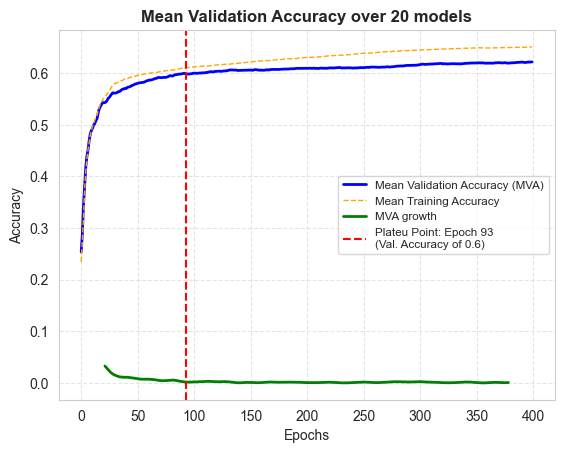

In [26]:


def growth_plateau(accuracy, moving_avg_range):
    """To find epoch at which training accuracy plateaus so we can use that as the static number of epochs for all experiments

    Args:
        accuracy (np.ndarray): array of validation accuracy at each epoch
        moving_avg_range (int): range of moving average to test for plateau

    Returns:
        tuple: data frame of accuracy growth, plateau epoch, plateau accuracy, accuracy growth at plateau
    """
    m = moving_avg_range
    epoch_nums = []
    epoch_growth = []
    plateau_vals = None
    
    #
    for i,val in enumerate(accuracy):
        if i <= m or i >= (len(accuracy) - m - 1):
            continue
        
        # average accuracy in the last 10 epochs and future 10 epochs
        past_range = accuracy[i-(m//2):i]
        future_range = accuracy[i+1:i+(m//2)+1]
        full_range = accuracy[i-(m//2):i+(m//2)+1]
        
        # Accuracy growth from past to future average
        growth = np.mean(future_range) - np.mean(past_range)
        std = np.std(full_range)
        epoch_nums.append(i)
        epoch_growth.append(growth)
        
        # Store epoch data if growth plateaus
        if growth > 0 and growth < 0.005 and std < 0.001 and plateau_vals is None:
            plateau_val_i = i
            plateau_val = val
            plateau_growth = growth
            plateau_vals = 1
            
    epoch_growth_df = pd.DataFrame.from_dict({'epoch': epoch_nums, 'growth':epoch_growth})
    return epoch_growth_df, plateau_val_i, plateau_val, plateau_growth

# Average accuracy of 20 experiments at each epoch 
mean_val_accuracy = np.mean([experiment['history']['val_accuracy'] for experiment in test_models['models'][list(test_models['models'].keys())[0]]], axis=0)
mean_train_accuracy = np.mean([experiment['history']['accuracy'] for experiment in test_models['models'][list(test_models['models'].keys())[0]]], axis=0)
moving_avg_range = 20

epoch_growth, plateau_epoch, plateau_accuracy, plateau_growth = growth_plateau(mean_val_accuracy, moving_avg_range)

plt.plot(range(len(mean_val_accuracy)), mean_val_accuracy, "b", label="Mean Validation Accuracy (MVA)", linewidth=2)
plt.plot(range(len(mean_train_accuracy)), mean_train_accuracy, "orange", label='Mean Training Accuracy', linewidth=1, linestyle='--')
plt.plot(epoch_growth['epoch'], epoch_growth['growth'], "green", label='MVA growth', linewidth=2)
plt.axvline(plateau_epoch, linestyle='--', color='red', label=f"Plateu Point: Epoch {plateau_epoch} \n(Val. Accuracy of {round(plateau_accuracy,2)})")
plt.legend(fontsize='small')
plt.title('Mean Validation Accuracy over 20 models', weight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.savefig("./figures/Plateau.png", bbox_inches='tight', dpi=300)


In [27]:
def get_confint(train_accuracies, test_accuracies):
    """Confidence intervals for accuracies

    Args:
        train_accuracies (list): list of mean train data accuracy per epoch
        test_accuracies (list): list of mean test data accuracy per epoch

    Returns:
        tuple: confidence interval for train accuracy, test accuracy
    """
    # CI cannot be created for experiment size  = 1
    if len(test_accuracies) > 1:
        # Confidence Interval of accuracy for each Hidden Neuron amount
        test_confint = stats.t.interval(
            confidence=0.95,
            df=len(test_accuracies) - 1,
            loc=np.mean(test_accuracies),
            scale=stats.sem(test_accuracies)
        )
        train_confint = stats.t.interval(
            confidence=0.95,
            df=len(train_accuracies) - 1,
            loc=np.mean(train_accuracies),
            scale=stats.sem(train_accuracies)
        )
        test_confint = (float(round(test_confint[0], 4)), float(round(test_confint[1], 4)))
        train_confint = (float(round(train_confint[0], 4)), float(round(train_confint[1], 4)))

    else:
        test_confint = f"Unable to construct Confidence Interval for sample size <= 1"
        
    return train_confint, test_confint

def get_stats(experiments):
    """Required stats from model outputs

    Args:
        experiments (list): list of (n = #experiments) models created for given set of model parameters 

    Returns:
        tuple: mean accuracy (train, test), confidence interval (train, test), mean training time, list of model test accuracies
    """
    test_accuracies = [model['test_eval'][1] for model in experiments] #Evaluated accuracy
    train_accuracies = [model['history']['accuracy'][-1] for model in experiments] # Train accuracy of final model
    training_times = [model['training_time'] for model in experiments]
    
    # Mean of train & test sets & time
    test_mean = round(np.mean(test_accuracies), 4)
    train_mean = round(np.mean(train_accuracies), 4)
    
    mean_min, mean_sec = divmod(round(np.mean(training_times), 0), 60)
    training_time_mean = f"{mean_min}m, {mean_sec}s"  
      
    train_confint, test_confint = get_confint(train_accuracies, test_accuracies)
    
    return train_mean, test_mean, train_confint, test_confint, training_time_mean, test_accuracies
  

def model_stats(models):
    """summarizes model stats

    Args:
        models (dict): model information from run_experiments()

    Returns:
        dict: model detail summary, top 10 model detail summary
    """
    
    columns=['parameter', 'parameter_value', 'train_accuracy', 'test_accuracy', 'train_confint', 'test_confint', 'avg_training_time', 'test_accuracies']
    all_model_details = []
    
    for value, experiments in models['models'].items():
        train_mean, test_mean, train_confint, test_confint, training_time_mean, test_accuracies = get_stats(experiments)                                 
        column_values = [models['parameter_details']['parameter'], value, train_mean, test_mean, train_confint, test_confint, training_time_mean, test_accuracies]
        all_model_details.append(pd.DataFrame([column_values], columns=columns))
    all_model_details = pd.concat(all_model_details)
    top_10_models = all_model_details.sort_values(by='test_accuracy', ascending=False).iloc[:10,:]
    
    return {'model_details': all_model_details, 'top_10': top_10_models}

In [28]:
def best_parameter_value(model_df):
    """Determines if less complex model is statistically different from more complex model

    Args:
        model_df (pd.DataFrame): data frame of model stats and other details for each change in parameter

    Returns:
        tuple: details of model with statistically best accuracy, data frame of model stats with p-values
    """
    # Current best performing model - by accuracy
    top_parameter = model_df.iloc[0, :]
        
    best_parameter = {'parameter_value':top_parameter['parameter_value'], 'test_accuracies': top_parameter['test_accuracies'], 'test_accuracy':top_parameter['test_accuracy'], 'p_value': ""}    
   
    alpha = 0.05
    for _, row in model_df.iloc[1:, :].iterrows():
        # ttest to compare all models to eachother
        t_stat, p_value = stats.ttest_rel(row['test_accuracies'], top_parameter['test_accuracies'])
        model_df.loc[model_df['parameter_value'] == row['parameter_value'], 'p-value'] = p_value
        # Store less complex model if it does not perform significantly different to current best model
        if p_value >= alpha and row['parameter_value'] < top_parameter['parameter_value'] and abs(row['test_confint'][0] - row['test_confint'][1]) < 0.05:
            best_parameter['p_value'] = f"No different from {top_parameter['parameter_value']} with a p-value of {p_value}"
            best_parameter['test_accuracies'] = row['test_accuracies']
            best_parameter['parameter_value'] = row['parameter_value']
    return best_parameter, model_df

In [29]:
# A: SGD
# A1. Update Number of Hidden Neurons
parameter_dict_sgd = {'hidden_neurons': 5,'hidden_layers': 1,'learning_rate': 0.01, 'optimizer': 'sgd'} # default parameters for SGD

hidden_neuron_range = range(5,21,5)
models_sgd_hn = run_experiments(x_data=x_data, y_data=y_data, parameter='hidden_neurons', parameter_values=hidden_neuron_range, parameter_dict_input=parameter_dict_sgd, num_experiments=10)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6210 - loss: 0.8267
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6156 - loss: 0.8245
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6066 - loss: 0.8281
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6102 - loss: 0.8369 
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6126 - loss: 0.8306
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6132 - loss: 0.8326
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6186 - loss: 0.8193
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6090 - loss: 0.8444
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6024 - loss: 0.8887
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6102 - loss: 0.8385


Models Generated for hidden_neurons: 5
Parameters left to model: 3
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6192 - loss: 0.8223
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6126 - loss: 0.8270
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6

In [ ]:
# Model statistics for variations in Hidden Neurons  
model_stats_sgd_hn = model_stats(models_sgd_hn)
num_hidden_neurons, model_stats_sgd_hn['top_10'] = best_parameter_value(model_stats_sgd_hn['top_10'])
parameter_dict_sgd['hidden_neurons'] = int(num_hidden_neurons['parameter_value'])
model_stats_sgd_hn['top_10'].to_csv('./figures/1_sgd_hn.csv')

print(model_stats_sgd_hn['top_10'])
print(num_hidden_neurons)
print(parameter_dict_sgd)


        parameter  parameter_value  train_accuracy  test_accuracy  \
0  hidden_neurons               20          0.6598         0.6194   
0  hidden_neurons               15          0.6553         0.6187   
0  hidden_neurons               10          0.6531         0.6172   
0  hidden_neurons                5          0.6430         0.6084   

      train_confint      test_confint avg_training_time  \
0   (0.657, 0.6627)  (0.6161, 0.6227)        0.0m, 9.0s   
0  (0.6534, 0.6573)  (0.6158, 0.6217)        0.0m, 9.0s   
0  (0.6494, 0.6569)  (0.6137, 0.6207)        0.0m, 9.0s   
0   (0.6351, 0.651)  (0.6016, 0.6151)       0.0m, 10.0s   

                                     test_accuracies   p-value  
0  [0.6227545142173767, 0.6173652410507202, 0.623...       NaN  
0  [0.6221556663513184, 0.6179640889167786, 0.610...  0.777219  
0  [0.6173652410507202, 0.613772451877594, 0.6143...  0.338271  
0  [0.5850299596786499, 0.613772451877594, 0.6185...  0.010913  
{'parameter_value': 10, 'test_acc

In [ ]:
# A2. Update Optimizer learning rate
power_range = np.arange(-4,-1, 0.2)
eta_range = 10**(power_range)
models_sgd_lr = run_experiments(x_data=x_data, y_data=y_data, parameter='optimizer', parameter_values=eta_range, parameter_dict_input=parameter_dict_sgd, num_experiments=10)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 977us/step - accuracy: 0.5946 - loss: 0.8777
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5976 - loss: 0.9025  
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - accuracy: 0.5988 - loss: 0.8609
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6006 - loss: 0.8782  
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5976 - loss: 0.8964  
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5994 - loss: 0.8734  
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5934 - loss: 0.8806  
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6006 - loss: 0.8857  
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6048 - loss: 0.8766  
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5970 - loss: 0.8848  


Models Generated for optimizer: 0.0001
Parameters left to model: 14
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6108 - loss: 0.8425  
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5910 - loss: 0.8719  
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [ ]:
# Model statistics for variations in Learning Rate  
model_stats_sgd_lr = model_stats(models_sgd_lr)

model_stats_sgd_lr['top_10']['parameter_value_log10'] = model_stats_sgd_lr['top_10']['parameter_value'].apply(
    lambda x: round(np.log10(x), 1)
)
best_lr, model_stats_sgd_lr['top_10'] = best_parameter_value(model_stats_sgd_lr['top_10'])
parameter_dict_sgd['learning_rate'] = float(10**(model_stats_sgd_lr['top_10'].iloc[0, -2]))
model_stats_sgd_lr['top_10'].to_csv('./figures/2_sgd_lr.csv')
print(model_stats_sgd_lr['top_10'])
print(best_lr)
print(parameter_dict_sgd)

   parameter  parameter_value  train_accuracy  test_accuracy  \
0  optimizer         0.003981          0.6677         0.6369   
0  optimizer         0.002512          0.6646         0.6367   
0  optimizer         0.001585          0.6614         0.6354   
0  optimizer         0.025119          0.6578         0.6348   
0  optimizer         0.015849          0.6629         0.6347   
0  optimizer         0.001000          0.6631         0.6341   
0  optimizer         0.010000          0.6648         0.6328   
0  optimizer         0.006310          0.6666         0.6323   
0  optimizer         0.039811          0.6527         0.6307   
0  optimizer         0.063096          0.6414         0.6292   

      train_confint      test_confint avg_training_time  \
0  (0.6647, 0.6707)  (0.6336, 0.6403)        0.0m, 9.0s   
0   (0.661, 0.6682)  (0.6339, 0.6395)        0.0m, 9.0s   
0   (0.6588, 0.664)  (0.6335, 0.6372)       0.0m, 10.0s   
0  (0.6552, 0.6604)  (0.6309, 0.6386)        0.0m, 9.0s   


In [ ]:
# A3. Change Number of Hidden Layers
num_hidden_layers = [1,2]
models_sgd_hl = run_experiments(x_data=x_data, y_data=y_data, parameter='hidden_layers', parameter_values=num_hidden_layers, parameter_dict_input=parameter_dict_sgd, num_experiments=10)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - accuracy: 0.5988 - loss: 0.8572
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - accuracy: 0.6024 - loss: 0.8551
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - accuracy: 0.5970 - loss: 0.8654
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step - accuracy: 0.6162 - loss: 0.8398
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step - accuracy: 0.5928 - loss: 0.8518
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 943us/step - accuracy: 0.5988 - loss: 0.8590
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step - accuracy: 0.6066 - loss: 0.8539
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step - accuracy: 0.6120 - loss: 0.8651
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step - accuracy: 0.6048 - loss: 0.8574
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 977us/step - accuracy: 0.5910 - loss: 0.8764


Models Generated for hidden_layers: 1
Parameters left to model: 1
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6144 - loss: 0.8261 
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6024 - loss: 0.8794 
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 997u

In [ ]:
# Model statistics for variations in Hidden Layers  
model_stats_sgd_hl = model_stats(models_sgd_hl)
best_layers, model_stats_sgd_hl['top_10'] = best_parameter_value(model_stats_sgd_hl['top_10'])
parameter_dict_sgd['hidden_layers'] = int(best_layers['parameter_value'])
model_stats_sgd_hl['top_10'].to_csv('./figures/3_sgd_hl.csv')
print(model_stats_sgd_hl['top_10'])
print(best_layers)
print(parameter_dict_sgd)

       parameter  parameter_value  train_accuracy  test_accuracy  \
0  hidden_layers                2          0.6326          0.604   
0  hidden_layers                1          0.6374          0.602   

      train_confint      test_confint avg_training_time  \
0  (0.6257, 0.6395)  (0.5988, 0.6091)        0.0m, 9.0s   
0  (0.6324, 0.6425)  (0.5963, 0.6078)        0.0m, 9.0s   

                                     test_accuracies   p-value  
0  [0.6143712401390076, 0.602395236492157, 0.5922...       NaN  
0  [0.598802387714386, 0.602395236492157, 0.59700...  0.616489  
{'parameter_value': 1, 'test_accuracies': [0.598802387714386, 0.602395236492157, 0.5970059633255005, 0.6161676645278931, 0.5928143858909607, 0.598802387714386, 0.6065868139266968, 0.6119760274887085, 0.6047903895378113, 0.5910179615020752], 'test_accuracy': np.float64(0.604), 'p_value': 'No different from 2 with a p-value of 0.6164891313024603'}
{'hidden_neurons': 10, 'hidden_layers': 1, 'learning_rate': 0.003981071705

In [ ]:
# B: Adam
# B1. Update Number of Hidden Neurons
parameter_dict_adam = {'hidden_neurons': 5,'hidden_layers': 1, 'learning_rate': 0.01, 'optimizer': 'adam'} # default parameters

hidden_neuron_range = range(5,21,5)
models_adam_hn = run_experiments(x_data=x_data, y_data=y_data, parameter='hidden_neurons', parameter_values=hidden_neuron_range, parameter_dict_input=parameter_dict_adam, num_experiments=10)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 992us/step - accuracy: 0.6371 - loss: 0.7916
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step - accuracy: 0.6144 - loss: 0.8140
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - accuracy: 0.6359 - loss: 0.7978
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step - accuracy: 0.6162 - loss: 0.8232
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6287 - loss: 0.7982 
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step - accuracy: 0.6222 - loss: 0.8192
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step - accuracy: 0.6425 - loss: 0.7910
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - accuracy: 0.6323 - loss: 0.8014
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step - accuracy: 0.6287 - loss: 0.7966
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 980us/step - accuracy: 0.6102 - loss: 0.8202


Models Generated for hidden_neurons: 5
Parameters left to model: 3
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6359 - loss: 0.8081  
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - accuracy: 0.6341 - loss: 0.8103
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 97

In [ ]:
# Model statistics for variations in Hidden Neurons  
model_stats_adam_hn = model_stats(models_adam_hn)
best_hidden_neurons, model_stats_adam_hn['top_10'] = best_parameter_value(model_stats_adam_hn['top_10'])
parameter_dict_adam['hidden_neurons'] = int(best_hidden_neurons['parameter_value'])
model_stats_adam_hn['top_10'].to_csv('./figures/4_adam_hn.csv')
print(model_stats_adam_hn['top_10'])
print(best_hidden_neurons)
print(parameter_dict_adam)

        parameter  parameter_value  train_accuracy  test_accuracy  \
0  hidden_neurons               10          0.6666         0.6337   
0  hidden_neurons               15          0.6672         0.6322   
0  hidden_neurons               20          0.6674         0.6322   
0  hidden_neurons                5          0.6590         0.6268   

      train_confint      test_confint avg_training_time  \
0   (0.665, 0.6682)  (0.6316, 0.6358)       0.0m, 10.0s   
0   (0.665, 0.6693)  (0.6265, 0.6379)        0.0m, 9.0s   
0  (0.6651, 0.6697)   (0.6283, 0.636)        0.0m, 9.0s   
0  (0.6551, 0.6629)  (0.6191, 0.6345)       0.0m, 10.0s   

                                     test_accuracies   p-value  
0  [0.6359281539916992, 0.6341317296028137, 0.632...       NaN  
0  [0.6299400925636292, 0.6239520907402039, 0.623...  0.613300  
0  [0.6371257305145264, 0.628742516040802, 0.6305...  0.183054  
0  [0.6371257305145264, 0.6143712401390076, 0.635...  0.107875  
{'parameter_value': 5, 'test_accu

In [ ]:
# B2. Update Optimizer learning rate
power_range = np.arange(-4,-1, 0.2)
eta_range = 10**(power_range)
models_adam_lr = run_experiments(x_data=x_data, y_data=y_data, parameter='optimizer', parameter_values=eta_range, parameter_dict_input=parameter_dict_adam, num_experiments=10)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - accuracy: 0.5940 - loss: 0.8946
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step - accuracy: 0.5695 - loss: 0.9635
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step - accuracy: 0.5713 - loss: 0.9190
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - accuracy: 0.5934 - loss: 0.9239
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step - accuracy: 0.5772 - loss: 0.9260
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - accuracy: 0.5707 - loss: 0.9228
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step - accuracy: 0.5958 - loss: 0.8904
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step - accuracy: 0.5940 - loss: 0.9053
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step - accuracy: 0.5946 - loss: 0.8907
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - accuracy: 0.5707 - loss: 0.9306


Models Generated for optimizer: 0.0001
Parameters left to model: 14
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - accuracy: 0.5958 - loss: 0.8826
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step - accuracy: 0.6018 - loss: 0.8936
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [ ]:
# Model statistics for variations in Learning Rate  
model_stats_adam_lr = model_stats(models_adam_lr)
model_stats_adam_lr['top_10']['parameter_value_log10'] = model_stats_adam_lr['top_10']['parameter_value'].apply(
    lambda x: round(np.log10(x), 1)
)
best_lr, model_stats_adam_lr['top_10'] = best_parameter_value(model_stats_adam_lr['top_10'])
parameter_dict_adam['learning_rate'] = float(10**(model_stats_sgd_lr['top_10'].iloc[0, -2]))
model_stats_adam_lr['top_10'].to_csv('./figures/5_adam_lr.csv')
print(model_stats_adam_lr['top_10'])
print(best_lr)
print(parameter_dict_adam)

   parameter  parameter_value  train_accuracy  test_accuracy  \
0  optimizer         0.025119          0.6502         0.6351   
0  optimizer         0.015849          0.6544         0.6307   
0  optimizer         0.002512          0.6575         0.6292   
0  optimizer         0.039811          0.6454         0.6277   
0  optimizer         0.001585          0.6539         0.6266   
0  optimizer         0.006310          0.6595         0.6264   
0  optimizer         0.003981          0.6570         0.6262   
0  optimizer         0.063096          0.6407         0.6256   
0  optimizer         0.010000          0.6571         0.6255   
0  optimizer         0.001000          0.6527         0.6213   

      train_confint      test_confint avg_training_time  \
0   (0.6474, 0.653)  (0.6317, 0.6386)        0.0m, 9.0s   
0  (0.6503, 0.6586)  (0.6245, 0.6368)        0.0m, 9.0s   
0  (0.6539, 0.6612)  (0.6238, 0.6346)        0.0m, 9.0s   
0  (0.6431, 0.6477)  (0.6217, 0.6337)        0.0m, 9.0s   


In [ ]:
# B3. Change Number of Hidden Layers
num_hidden_layers = [1,2]
models_adam_hl = run_experiments(x_data=x_data, y_data=y_data, parameter='hidden_layers', parameter_values=num_hidden_layers, parameter_dict_input=parameter_dict_adam, num_experiments=10)

 1/53 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.5938 - loss: 0.8052

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6311 - loss: 0.8000 
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step - accuracy: 0.6269 - loss: 0.7956
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - accuracy: 0.6371 - loss: 0.7972
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - accuracy: 0.6317 - loss: 0.7984
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - accuracy: 0.6222 - loss: 0.8126
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step - accuracy: 0.6305 - loss: 0.8012
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6305 - loss: 0.8022 
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - accuracy: 0.6216 - loss: 0.8045
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - accuracy: 0.6365 - loss: 0.8013
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6293 - loss: 0.8066 


Models Generated for hidden_layers: 1
Parameters left to model: 1
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6180 - loss: 0.8163 
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step - accuracy: 0.6281 - loss: 0.7961
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/st

In [ ]:
# Model statistics for variations in Hidden Layers
model_stats_adam_hl = model_stats(models_adam_hl)
best_layers, model_stats_adam_hl['top_10'] = best_parameter_value(model_stats_adam_hl['top_10'])
parameter_dict_adam['hidden_layers'] = int(best_layers['parameter_value'])
model_stats_adam_hl['top_10'].to_csv('./figures/6_adam_hl.csv')
print(model_stats_adam_hl['top_10'])
print(best_layers)
print(parameter_dict_adam)

       parameter  parameter_value  train_accuracy  test_accuracy  \
0  hidden_layers                2          0.6629         0.6301   
0  hidden_layers                1          0.6611         0.6298   

      train_confint      test_confint avg_training_time  \
0  (0.6606, 0.6651)  (0.6241, 0.6361)       0.0m, 15.0s   
0   (0.6562, 0.666)  (0.6261, 0.6335)        0.0m, 9.0s   

                                     test_accuracies   p-value  
0  [0.6179640889167786, 0.6281437277793884, 0.634...       NaN  
0  [0.6311377286911011, 0.6269460916519165, 0.637...  0.877027  
{'parameter_value': 1, 'test_accuracies': [0.6311377286911011, 0.6269460916519165, 0.6371257305145264, 0.6317365169525146, 0.6221556663513184, 0.6305389404296875, 0.6305389404296875, 0.6215568780899048, 0.6365269422531128, 0.6293413043022156], 'test_accuracy': np.float64(0.6301), 'p_value': 'No different from 2 with a p-value of 0.8770265435208694'}
{'hidden_neurons': 5, 'hidden_layers': 1, 'learning_rate': 0.003981071

In [ ]:
# Final optimized SGD model
models_sgd_final = run_experiments(x_data=x_data, y_data=y_data, parameter='hidden_layers', parameter_values=[parameter_dict_sgd['hidden_layers']], parameter_dict_input=parameter_dict_sgd, num_experiments=10)


In [ ]:
# Model stats for final optimized SGD model
model_stats_sgd_final = model_stats(models_sgd_final)
model_stats_sgd_final['top_10'].to_csv('./figures/7_sgd_final.csv')
print(model_stats_sgd_hl['top_10'])
print(best_layers)
print(parameter_dict_sgd)

       parameter  parameter_value  train_accuracy  test_accuracy  \
0  hidden_layers                2          0.6326          0.604   
0  hidden_layers                1          0.6374          0.602   

      train_confint      test_confint avg_training_time  \
0  (0.6257, 0.6395)  (0.5988, 0.6091)        0.0m, 9.0s   
0  (0.6324, 0.6425)  (0.5963, 0.6078)        0.0m, 9.0s   

                                     test_accuracies   p-value  
0  [0.6143712401390076, 0.602395236492157, 0.5922...       NaN  
0  [0.598802387714386, 0.602395236492157, 0.59700...  0.616489  
{'parameter_value': 1, 'test_accuracies': [0.6311377286911011, 0.6269460916519165, 0.6371257305145264, 0.6317365169525146, 0.6221556663513184, 0.6305389404296875, 0.6305389404296875, 0.6215568780899048, 0.6365269422531128, 0.6293413043022156], 'test_accuracy': np.float64(0.6301), 'p_value': 'No different from 2 with a p-value of 0.8770265435208694'}
{'hidden_neurons': 10, 'hidden_layers': 1, 'learning_rate': 0.00398107

In [ ]:
# Final optimized Adam model
models_adam_final = run_experiments(x_data=x_data, y_data=y_data, parameter='hidden_layers', parameter_values=[parameter_dict_adam['hidden_layers']], parameter_dict_input=parameter_dict_adam, num_experiments=10)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6150 - loss: 0.8061 
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6383 - loss: 0.7968 
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6323 - loss: 0.8009 
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6246 - loss: 0.8040 
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6347 - loss: 0.7974 
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6162 - loss: 0.8131 
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - accuracy: 0.6395 - loss: 0.7945
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6431 - loss: 0.7899  
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step - accuracy: 0.6210 - loss: 0.8120
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - accuracy: 0.6293 - loss: 0.7985


Models Generated for hidden_layers: 1
Parameters left to model: 0


In [ ]:
# Final optimized Adam model
model_stats_adam_final = model_stats(models_adam_final)
model_stats_adam_final['top_10'].to_csv('./figures/8_adam_final.csv')
print(model_stats_adam_final['top_10'])
print(best_layers)
print(parameter_dict_adam)

       parameter  parameter_value  train_accuracy  test_accuracy  \
0  hidden_layers                1          0.6584         0.6294   

      train_confint      test_confint avg_training_time  \
0  (0.6536, 0.6631)  (0.6223, 0.6365)       0.0m, 10.0s   

                                     test_accuracies  
0  [0.6149700880050659, 0.6383233666419983, 0.632...  
{'parameter_value': 1, 'test_accuracies': [0.6311377286911011, 0.6269460916519165, 0.6371257305145264, 0.6317365169525146, 0.6221556663513184, 0.6305389404296875, 0.6305389404296875, 0.6215568780899048, 0.6365269422531128, 0.6293413043022156], 'test_accuracy': np.float64(0.6301), 'p_value': 'No different from 2 with a p-value of 0.8770265435208694'}
{'hidden_neurons': 5, 'hidden_layers': 1, 'learning_rate': 0.003981071705534973, 'optimizer': 'adam'}


In [ ]:
# Compare best SGD and Adam to determine best overall model
t_stat, p_value = stats.ttest_rel(model_stats_sgd_final['top_10']['test_accuracies'].values[0], model_stats_adam_final['top_10']['test_accuracies'].values[0])
print(p_value)

6.628027095109288e-05


In [709]:
# Final model and prdictions
from sklearn.metrics import confusion_matrix
print(parameter_dict_adam)
final_model = generate_NN(x_data, y_data, batch_size=32, epochs=103, verbose=0, validation_data=None, **parameter_dict_adam)
y_prob = final_model['model'].predict(x_data['x_test'])
y_pred = np.argmax(y_prob, axis=1)


{'hidden_neurons': 5, 'hidden_layers': 1, 'learning_rate': 0.003981071705534973, 'optimizer': 'adam'}
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - accuracy: 0.6216 - loss: 0.8094
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step


In [ ]:
# Confusion matrix
y_test = y_data['y_test'].to_numpy()
confusion_mat = confusion_matrix(y_test, y_pred=y_pred)
print(confusion_mat)
percent_confusion = np.round((confusion_mat / np.sum(confusion_mat, axis=0))*100, 2)
print(percent_confusion)

[[238  95   2   0]
 [ 55 532 167   2]
 [  5 205 244  21]
 [  0  14  66  24]]
[[79.87 11.23  0.42  0.  ]
 [18.46 62.88 34.86  4.26]
 [ 1.68 24.23 50.94 44.68]
 [ 0.    1.65 13.78 51.06]]


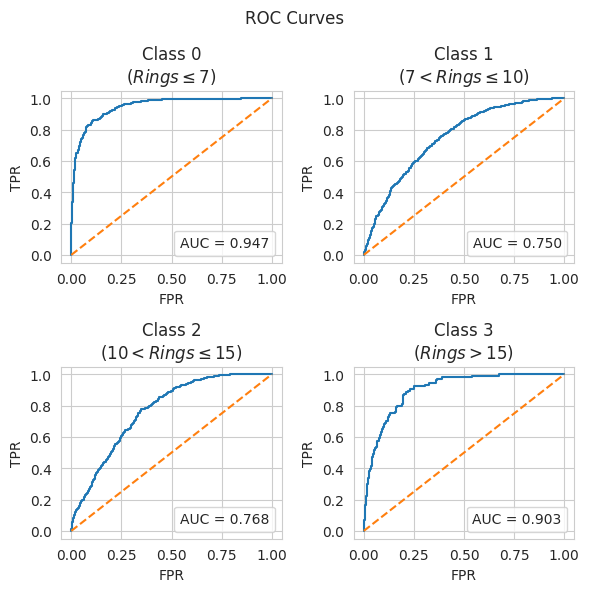

In [ ]:
# ROC Curve
from sklearn.metrics import roc_auc_score, roc_curve,auc
from sklearn.preprocessing import label_binarize

model_metrics = {}
for i in range(4): # Have to separate each class and binarise it
    y_test_temp = (y_test == i).astype(int)
    y_prob_temp = y_prob[:, i]
    model_metrics[i] = {'y_test': y_test_temp, 'roc': roc_curve(y_true=y_test_temp, y_score=y_prob_temp)}



classes_list = ["Class 0\n"r"($Rings \leq 7$)", "Class 1\n"r"($7 < Rings \leq10$)", "Class 2\n"r"($10 < Rings \leq 15$)", "Class 3\n"r"($Rings > 15$)"]
fig, axes = plt.subplots(2,2, figsize=(6,6))
for i, ax in enumerate(axes.flatten()):
    fpr, tpr, thresh = model_metrics[i]['roc']
    roc_auc = auc(fpr, tpr)    
    model_metrics[i]['auc'] = roc_auc
    ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")  # random baseline
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title(classes_list[i])
    ax.legend(handletextpad=0, handlelength=0)
    
fig.suptitle("ROC Curves")
fig.tight_layout()

fig.savefig('figures/ROC_curves.png', bbox_inches='tight', dpi=300)

In [728]:
mean_auc = 0
for i in range(4):
    mean_auc += model_metrics[i]['auc']
print(mean_auc/4)

0.8419293652703337
